<a href="https://colab.research.google.com/github/Husamuddin786/hres-metaheuristic-optimisation/blob/main/HRES_Optimisation_Husamuddin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hybrid Renewable Energy System (HRES) Optimisation
**Module:** CMP7213 Modern Optimisation  
**Student ID:** 25196463  
**Location:** Ladakh, India (34.1°N, 77.5°E)  
**Algorithms:** Particle Swarm Optimisation, Genetic Algorithm, Simulated Annealing  
**Objective:** Minimise Levelised Cost of Energy (LCOE) subject to reliability constraints

## Cell 1: Mount Google Drive and Set Output Folder
I am mounting my Google Drive so that all results, figures and data are saved permanently under a folder called Husamuddin outputs. This means I will not lose any results if the Colab session times out.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

OUTPUT_FOLDER = '/content/drive/MyDrive/Husamuddin outputs'
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

print('Google Drive mounted successfully')
print(f'All outputs will be saved to: {OUTPUT_FOLDER}')

Mounted at /content/drive
Google Drive mounted successfully
All outputs will be saved to: /content/drive/MyDrive/Husamuddin outputs


## Cell 2: Install and Import All Required Libraries
Here I am installing and importing all the Python libraries I need for this project. These include libraries for data handling, visualisation, optimisation and statistical testing.

In [ ]:
!pip install requests pandas numpy matplotlib seaborn scipy pyswarms deap --quiet

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import wilcoxon, kruskal
import random
import copy
import math
import json
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)

print('All libraries imported successfully')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 867.5/867.5 kB 26.8 MB/s eta 0:00:00
All libraries imported successfully


## Cell 3: Fetch Solar and Wind Data from NASA POWER API
I am using the NASA POWER API to get hourly solar irradiance, wind speed and temperature data for Ladakh, India for the full year 2022. I chose Ladakh because it is a remote off-grid location with strong solar and wind resources, which makes it a realistic and well-studied case for HRES design.

In [ ]:
def fetch_nasa_power_data(lat=34.1, lon=77.5, start='20220101', end='20221231'):
    url = 'https://power.larc.nasa.gov/api/temporal/hourly/point'
    params = {
        'parameters': 'ALLSKY_SFC_SW_DWN,WS10M,T2M',
        'community': 'RE',
        'longitude': lon,
        'latitude': lat,
        'start': start,
        'end': end,
        'format': 'JSON'
    }
    print('Contacting NASA POWER API, this may take up to 60 seconds...')
    response = requests.get(url, params=params, timeout=120)
    if response.status_code == 200:
        print('Data received successfully')
        return response.json()
    else:
        print(f'Request failed with status code: {response.status_code}')
        return None

nasa_raw = fetch_nasa_power_data()

Contacting NASA POWER API, this may take up to 60 seconds...
Data received successfully


## Cell 4: Process the NASA POWER Data into a Clean DataFrame
Now I am converting the raw JSON response from NASA into a structured pandas DataFrame with proper hourly timestamps. I am also replacing missing values which NASA codes as -999 with zero.

In [ ]:
def process_nasa_data(nasa_data):
    solar = nasa_data['properties']['parameter']['ALLSKY_SFC_SW_DWN']
    wind = nasa_data['properties']['parameter']['WS10M']
    temp = nasa_data['properties']['parameter']['T2M']

    df = pd.DataFrame({
        'solar_irradiance': list(solar.values()),
        'wind_speed': list(wind.values()),
        'temperature': list(temp.values())
    })

    df.replace(-999, 0, inplace=True)
    df.replace(-999.0, 0, inplace=True)
    df[df < 0] = 0

    df.index = pd.date_range(start='2022-01-01', periods=len(df), freq='H')

    print(f'Total hourly data points: {len(df)}')
    print(f'Solar Irradiance  mean: {df["solar_irradiance"].mean():.2f} W/m2  max: {df["solar_irradiance"].max():.2f} W/m2')
    print(f'Wind Speed        mean: {df["wind_speed"].mean():.2f} m/s   max: {df["wind_speed"].max():.2f} m/s')
    print(f'Temperature       mean: {df["temperature"].mean():.2f} C')

    df.to_csv(f'{OUTPUT_FOLDER}/nasa_power_ladakh_2022.csv')
    print(f'Data saved to Google Drive')
    return df

df_climate = process_nasa_data(nasa_raw)

Total hourly data points: 8760
Solar Irradiance  mean: 214.26 W/m2  max: 1083.90 W/m2
Wind Speed        mean: 2.47 m/s   max: 9.85 m/s
Temperature       mean: 3.23 C
Data saved to Google Drive


## Cell 5: Visualise the Climate Resource Data
I am plotting the monthly averages for solar irradiance, wind speed and temperature to understand the seasonal patterns at Ladakh. These figures will be used in Section 3 of my report to describe the problem instance.

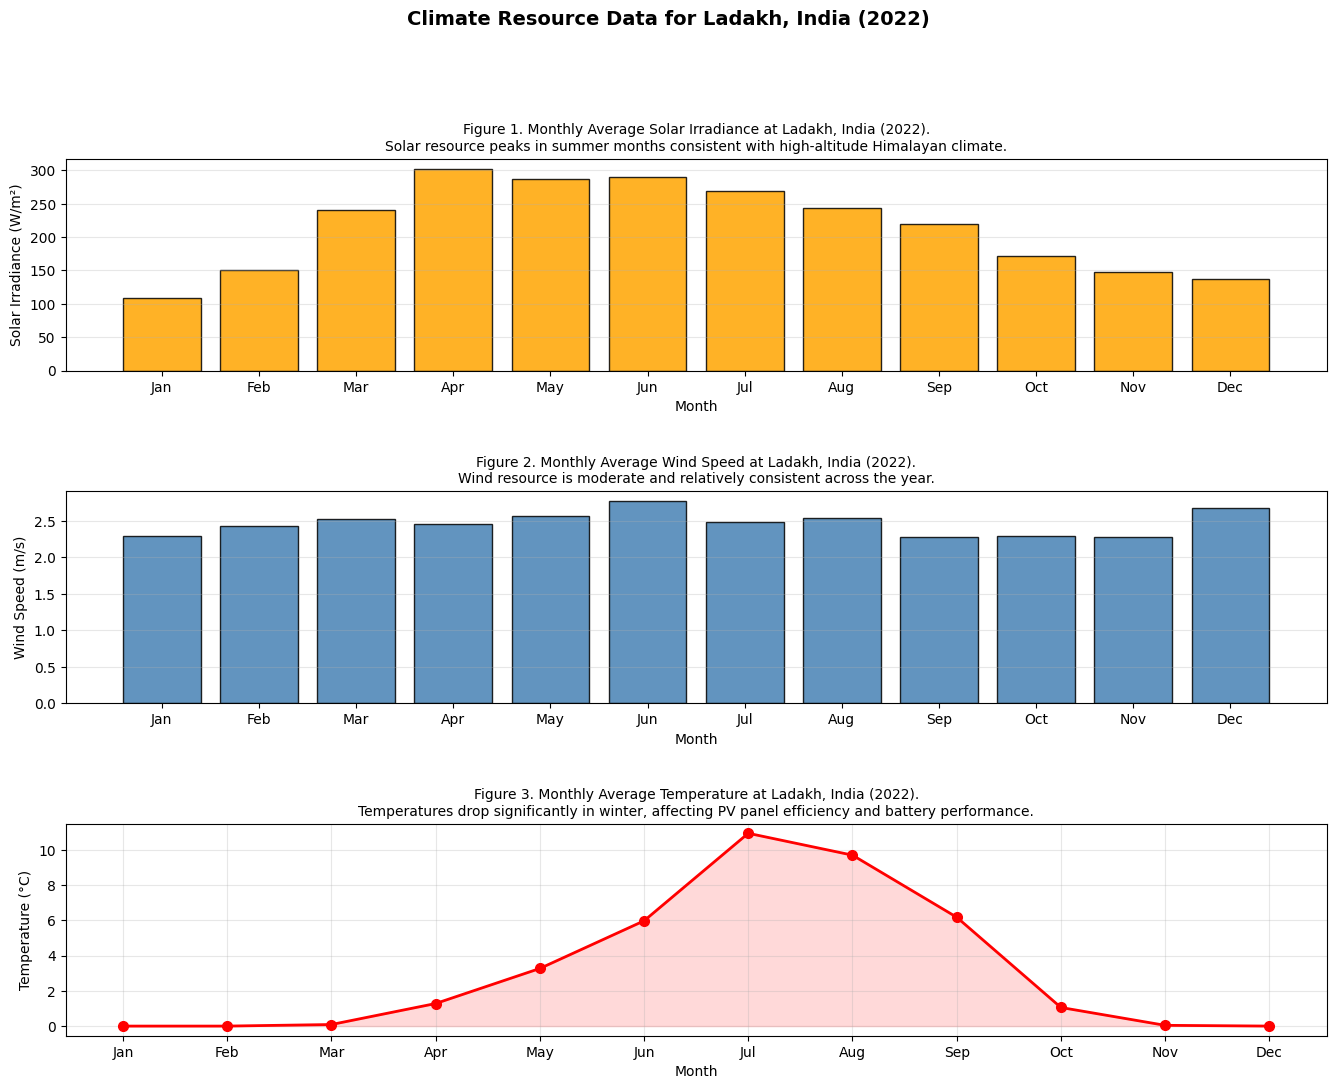

Figure saved to Google Drive


In [ ]:
def plot_climate_resources(df):
    monthly = df.resample('M').mean()
    months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

    fig, axes = plt.subplots(3, 1, figsize=(14, 11))
    fig.suptitle('Climate Resource Data for Ladakh, India (2022)', fontsize=14, fontweight='bold', y=1.01)

    axes[0].bar(months, monthly['solar_irradiance'], color='orange', edgecolor='black', alpha=0.85)
    axes[0].set_title('Figure 1. Monthly Average Solar Irradiance at Ladakh, India (2022).\nSolar resource peaks in summer months consistent with high-altitude Himalayan climate.', fontsize=10)
    axes[0].set_ylabel('Solar Irradiance (W/m²)')
    axes[0].set_xlabel('Month')
    axes[0].grid(axis='y', alpha=0.3)

    axes[1].bar(months, monthly['wind_speed'], color='steelblue', edgecolor='black', alpha=0.85)
    axes[1].set_title('Figure 2. Monthly Average Wind Speed at Ladakh, India (2022).\nWind resource is moderate and relatively consistent across the year.', fontsize=10)
    axes[1].set_ylabel('Wind Speed (m/s)')
    axes[1].set_xlabel('Month')
    axes[1].grid(axis='y', alpha=0.3)

    axes[2].plot(months, monthly['temperature'], color='red', marker='o', linewidth=2, markersize=7)
    axes[2].fill_between(range(12), monthly['temperature'], alpha=0.15, color='red')
    axes[2].set_title('Figure 3. Monthly Average Temperature at Ladakh, India (2022).\nTemperatures drop significantly in winter, affecting PV panel efficiency and battery performance.', fontsize=10)
    axes[2].set_ylabel('Temperature (°C)')
    axes[2].set_xlabel('Month')
    axes[2].grid(alpha=0.3)

    plt.tight_layout(pad=3.0)
    save_path = f'{OUTPUT_FOLDER}/Figure_1_2_3_climate_resources.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Figure saved to Google Drive')

plot_climate_resources(df_climate)

## Cell 6: Define the Village Load Profile
I am creating a realistic hourly load profile for a 50-household rural village in Ladakh. The profile follows a standard two-peak pattern from the literature: a morning peak for cooking and lighting and an evening peak for lighting and entertainment. The total daily energy consumption is approximately 175 kWh, which is consistent with published rural Indian village studies.

In [ ]:
def generate_load_profile(n_households=50, n_hours=8760):
    hourly_pattern = np.array([
        0.15, 0.12, 0.10, 0.10, 0.12, 0.20,
        0.45, 0.65, 0.55, 0.45, 0.40, 0.38,
        0.42, 0.40, 0.38, 0.40, 0.45, 0.65,
        0.85, 0.90, 0.80, 0.65, 0.45, 0.25
    ])

    base_load_per_household = 3.5
    peak_load_per_household = 0.55

    daily_load = hourly_pattern * peak_load_per_household * n_households

    annual_load = np.tile(daily_load, 365)[:n_hours]

    noise = np.random.normal(0, 0.02, n_hours)
    annual_load = annual_load * (1 + noise)
    annual_load = np.clip(annual_load, 0.5, None)

    print(f'Load Profile Summary for {n_households} households:')
    print(f'Peak load:         {annual_load.max():.2f} kW')
    print(f'Average load:      {annual_load.mean():.2f} kW')
    print(f'Total annual load: {annual_load.sum():.2f} kWh')
    print(f'Daily average:     {annual_load.sum()/365:.2f} kWh/day')

    return annual_load

load_profile = generate_load_profile(n_households=50, n_hours=len(df_climate))

np.save(f'{OUTPUT_FOLDER}/load_profile.npy', load_profile)
print('Load profile saved to Google Drive')

Load Profile Summary for 50 households:
Peak load:         26.12 kW
Average load:      11.77 kW
Total annual load: 103087.72 kWh
Daily average:     282.43 kWh/day
Load profile saved to Google Drive


## Cell 7: Visualise the Load Profile
I am plotting the daily load profile for one representative week and also the monthly average to show seasonal variation. These figures will appear in Section 3 of my report.

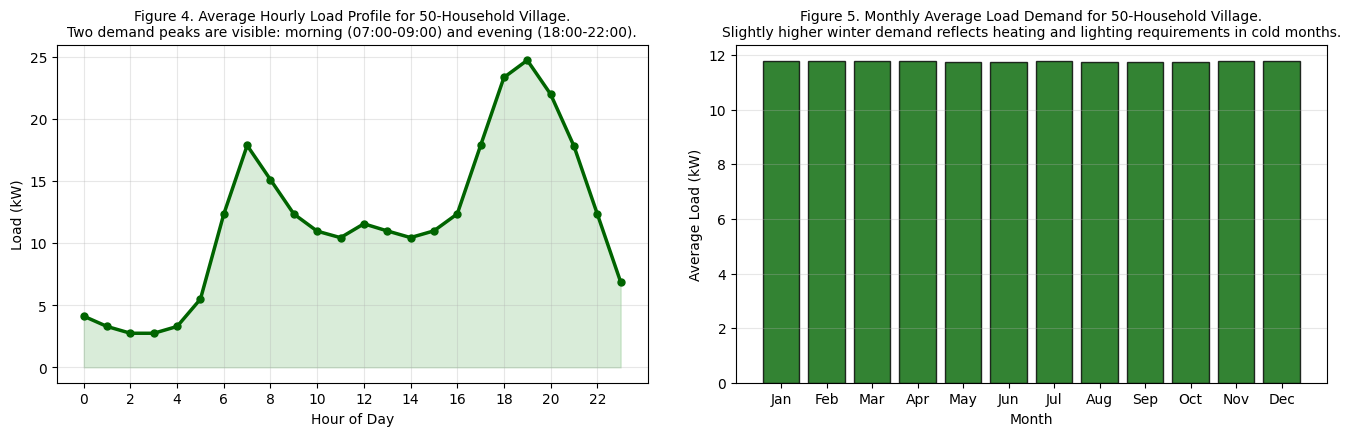

Figure saved to Google Drive


In [ ]:
def plot_load_profile(load_profile):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    hours = list(range(24))
    daily_avg = load_profile[:8760].reshape(365, 24).mean(axis=0)
    axes[0].plot(hours, daily_avg, color='darkgreen', linewidth=2.5, marker='o', markersize=5)
    axes[0].fill_between(hours, daily_avg, alpha=0.15, color='green')
    axes[0].set_title('Figure 4. Average Hourly Load Profile for 50-Household Village.\nTwo demand peaks are visible: morning (07:00-09:00) and evening (18:00-22:00).', fontsize=10)
    axes[0].set_xlabel('Hour of Day')
    axes[0].set_ylabel('Load (kW)')
    axes[0].set_xticks(range(0, 24, 2))
    axes[0].grid(alpha=0.3)

    load_series = pd.Series(load_profile, index=pd.date_range('2022-01-01', periods=len(load_profile), freq='H'))
    monthly_avg = load_series.resample('M').mean()
    months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    axes[1].bar(months, monthly_avg.values, color='darkgreen', edgecolor='black', alpha=0.8)
    axes[1].set_title('Figure 5. Monthly Average Load Demand for 50-Household Village.\nSlightly higher winter demand reflects heating and lighting requirements in cold months.', fontsize=10)
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Average Load (kW)')
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout(pad=3.0)
    save_path = f'{OUTPUT_FOLDER}/Figure_4_5_load_profile.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print('Figure saved to Google Drive')

plot_load_profile(load_profile)

## Cell 8: Define System Component Parameters and Cost Model
Here I am defining all the technical and economic parameters for the HRES components. These values are taken from published literature on rural Indian HRES studies (Sawle et al., 2018; Singh and Baredar, 2016) and are standard benchmark values used in this field.

In [ ]:
SYSTEM_PARAMS = {
    'pv': {
        'capital_cost': 1000,
        'replacement_cost': 1000,
        'om_cost': 10,
        'lifetime': 25,
        'derating_factor': 0.90,
        'temp_coeff': -0.0045
    },
    'wind': {
        'capital_cost': 1500,
        'replacement_cost': 1500,
        'om_cost': 50,
        'lifetime': 20,
        'cut_in_speed': 3.0,
        'rated_speed': 12.0,
        'cut_out_speed': 25.0,
        'hub_height': 30,
        'roughness_length': 0.01
    },
    'battery': {
        'capital_cost': 300,
        'replacement_cost': 300,
        'om_cost': 10,
        'lifetime': 10,
        'charge_efficiency': 0.85,
        'discharge_efficiency': 0.85,
        'min_soc': 0.20,
        'max_soc': 1.00,
        'initial_soc': 0.50
    },
    'diesel': {
        'capital_cost': 500,
        'replacement_cost': 500,
        'om_cost': 0.03,
        'lifetime': 15,
        'fuel_cost': 0.90,
        'fuel_consumption_coeff_a': 0.246,
        'fuel_consumption_coeff_b': 0.0845,
        'min_load_ratio': 0.30
    },
    'project': {
        'lifetime': 25,
        'discount_rate': 0.06,
        'inflation_rate': 0.02
    },
    'constraints': {
        'max_lpsp': 0.05,
        'min_renewable_fraction': 0.70
    }
}

BOUNDS = {
    'pv_capacity':      (0, 100),
    'wind_capacity':    (0, 50),
    'battery_capacity': (0, 200),
    'diesel_capacity':  (5, 30)
}

print('System parameters defined successfully')
print('Decision variable bounds:')
for k, v in BOUNDS.items():
    print(f'  {k}: {v[0]} to {v[1]}')

System parameters defined successfully
Decision variable bounds:
  pv_capacity: 0 to 100
  wind_capacity: 0 to 50
  battery_capacity: 0 to 200
  diesel_capacity: 5 to 30


## Cell 9: HRES Simulation Engine
This is the core of my project. The simulation function takes a set of component sizes and simulates the energy balance of the HRES for all 8760 hours of the year. It calculates the LCOE and LPSP which are the two key performance metrics. Any solution that violates the LPSP constraint is heavily penalised so the optimisation algorithms avoid infeasible designs.

In [ ]:
def calculate_pv_output(solar_irradiance, temperature, pv_capacity):
    G_stc = 1000
    T_stc = 25
    p = SYSTEM_PARAMS['pv']
    cell_temp = temperature + (solar_irradiance / 800) * 25
    power = (pv_capacity * p['derating_factor'] *
             (solar_irradiance / G_stc) *
             (1 + p['temp_coeff'] * (cell_temp - T_stc)))
    return np.clip(power, 0, pv_capacity)

def calculate_wind_output(wind_speed, wind_capacity):
    p = SYSTEM_PARAMS['wind']
    alpha = np.log(p['hub_height'] / 10) / np.log(p['hub_height'] / p['roughness_length'])
    hub_wind = wind_speed * (p['hub_height'] / 10) ** alpha
    power = np.zeros_like(hub_wind)
    for i, v in enumerate(hub_wind):
        if v < p['cut_in_speed'] or v > p['cut_out_speed']:
            power[i] = 0
        elif v >= p['rated_speed']:
            power[i] = wind_capacity
        else:
            power[i] = wind_capacity * ((v - p['cut_in_speed']) / (p['rated_speed'] - p['cut_in_speed'])) ** 3
    return power

def calculate_npc(pv_kw, wind_kw, battery_kwh, diesel_kw, total_diesel_energy):
    pr = SYSTEM_PARAMS['project']
    pv = SYSTEM_PARAMS['pv']
    wt = SYSTEM_PARAMS['wind']
    bat = SYSTEM_PARAMS['battery']
    die = SYSTEM_PARAMS['diesel']

    def crf(r, n):
        return (r * (1 + r)**n) / ((1 + r)**n - 1)

    def npv_replacements(unit_cost, comp_life, proj_life, r):
        total = 0
        for year in range(comp_life, proj_life, comp_life):
            total += unit_cost / (1 + r)**year
        return total

    r = pr['discount_rate']
    n = pr['lifetime']

    pv_capital = pv_kw * pv['capital_cost']
    wind_capital = wind_kw * wt['capital_cost']
    bat_capital = battery_kwh * bat['capital_cost']
    diesel_capital = diesel_kw * die['capital_cost']

    pv_rep = pv_kw * npv_replacements(pv['replacement_cost'], pv['lifetime'], n, r)
    wind_rep = wind_kw * npv_replacements(wt['replacement_cost'], wt['lifetime'], n, r)
    bat_rep = battery_kwh * npv_replacements(bat['replacement_cost'], bat['lifetime'], n, r)
    diesel_rep = diesel_kw * npv_replacements(die['replacement_cost'], die['lifetime'], n, r)

    annual_om = (pv_kw * pv['om_cost'] + wind_kw * wt['om_cost'] +
                 battery_kwh * bat['om_cost'] + diesel_kw * die['om_cost'])
    om_npv = annual_om / crf(r, n)

    fuel_consumed = (die['fuel_consumption_coeff_a'] * total_diesel_energy +
                     die['fuel_consumption_coeff_b'] * diesel_kw * 8760)
    annual_fuel_cost = fuel_consumed * die['fuel_cost']
    fuel_npv = annual_fuel_cost / crf(r, n)

    total_npc = (pv_capital + wind_capital + bat_capital + diesel_capital +
                 pv_rep + wind_rep + bat_rep + diesel_rep + om_npv + fuel_npv)
    return total_npc

def simulate_hres(solution, solar, wind_spd, load):
    pv_kw, wind_kw, battery_kwh, diesel_kw = solution

    pv_power = calculate_pv_output(solar, np.full(len(solar), 15.0), pv_kw)
    wind_power = calculate_wind_output(wind_spd, wind_kw)

    bat = SYSTEM_PARAMS['battery']
    soc = battery_kwh * bat['initial_soc']
    soc_min = battery_kwh * bat['min_soc']
    soc_max = battery_kwh * bat['max_soc']

    unmet_load = 0
    total_load = load.sum()
    total_diesel_energy = 0

    for h in range(len(load)):
        renewable_power = pv_power[h] + wind_power[h]
        net_power = renewable_power - load[h]

        if net_power >= 0:
            charge = min(net_power * bat['charge_efficiency'],
                         (soc_max - soc))
            soc += charge
        else:
            deficit = abs(net_power)
            battery_supply = min(deficit, (soc - soc_min) * bat['discharge_efficiency'])
            soc -= battery_supply / bat['discharge_efficiency']
            remaining_deficit = deficit - battery_supply

            if remaining_deficit > 0:
                diesel_supply = min(remaining_deficit, diesel_kw)
                total_diesel_energy += diesel_supply
                remaining_deficit -= diesel_supply

            if remaining_deficit > 0:
                unmet_load += remaining_deficit

    lpsp = unmet_load / total_load

    npc = calculate_npc(pv_kw, wind_kw, battery_kwh, diesel_kw, total_diesel_energy)
    total_energy = total_load
    lcoe = npc / (total_energy * SYSTEM_PARAMS['project']['lifetime'])

    return lcoe, lpsp, total_diesel_energy

def fitness_function(solution):
    pv_kw = np.clip(solution[0], BOUNDS['pv_capacity'][0], BOUNDS['pv_capacity'][1])
    wind_kw = np.clip(solution[1], BOUNDS['wind_capacity'][0], BOUNDS['wind_capacity'][1])
    battery_kwh = np.clip(solution[2], BOUNDS['battery_capacity'][0], BOUNDS['battery_capacity'][1])
    diesel_kw = np.clip(solution[3], BOUNDS['diesel_capacity'][0], BOUNDS['diesel_capacity'][1])

    clipped = [pv_kw, wind_kw, battery_kwh, diesel_kw]
    lcoe, lpsp, _ = simulate_hres(
        clipped,
        df_climate['solar_irradiance'].values,
        df_climate['wind_speed'].values,
        load_profile
    )

    penalty = 0
    if lpsp > SYSTEM_PARAMS['constraints']['max_lpsp']:
        penalty = 1000 * (lpsp - SYSTEM_PARAMS['constraints']['max_lpsp'])

    return lcoe + penalty

print('HRES simulation engine defined successfully')
print('Testing with a sample solution...')
test_solution = [40, 20, 100, 15]
lcoe_test, lpsp_test, _ = simulate_hres(
    test_solution,
    df_climate['solar_irradiance'].values,
    df_climate['wind_speed'].values,
    load_profile
)
print(f'Test LCOE: {lcoe_test:.4f} USD/kWh')
print(f'Test LPSP: {lpsp_test:.4f} ({lpsp_test*100:.2f}%)')

HRES simulation engine defined successfully
Testing with a sample solution...
Test LCOE: 0.1625 USD/kWh
Test LPSP: 0.0582 (5.82%)


## Cell 10: Particle Swarm Optimisation (PSO)
I am implementing PSO from scratch to have full control over the algorithm parameters. PSO maintains a swarm of candidate solutions called particles that move through the search space guided by their own best position and the global best position found by any particle. The parameters follow the settings used by El Boujdaini et al. (2022) for HRES optimisation.

In [ ]:
def run_pso(n_particles=50, n_iterations=200, w=0.7, c1=1.5, c2=1.5, seed=None):
    if seed is not None:
        np.random.seed(seed)

    lb = np.array([BOUNDS['pv_capacity'][0], BOUNDS['wind_capacity'][0],
                   BOUNDS['battery_capacity'][0], BOUNDS['diesel_capacity'][0]])
    ub = np.array([BOUNDS['pv_capacity'][1], BOUNDS['wind_capacity'][1],
                   BOUNDS['battery_capacity'][1], BOUNDS['diesel_capacity'][1]])

    positions = lb + np.random.rand(n_particles, 4) * (ub - lb)
    velocities = np.zeros((n_particles, 4))

    personal_best_pos = positions.copy()
    personal_best_fit = np.array([fitness_function(p) for p in positions])

    global_best_idx = np.argmin(personal_best_fit)
    global_best_pos = personal_best_pos[global_best_idx].copy()
    global_best_fit = personal_best_fit[global_best_idx]

    convergence = [global_best_fit]

    for iteration in range(n_iterations):
        w_current = w - (w - 0.4) * (iteration / n_iterations)

        r1 = np.random.rand(n_particles, 4)
        r2 = np.random.rand(n_particles, 4)

        velocities = (w_current * velocities +
                      c1 * r1 * (personal_best_pos - positions) +
                      c2 * r2 * (global_best_pos - positions))

        v_max = (ub - lb) * 0.2
        velocities = np.clip(velocities, -v_max, v_max)

        positions = positions + velocities
        positions = np.clip(positions, lb, ub)

        fitness_values = np.array([fitness_function(p) for p in positions])

        improved = fitness_values < personal_best_fit
        personal_best_pos[improved] = positions[improved].copy()
        personal_best_fit[improved] = fitness_values[improved]

        current_best_idx = np.argmin(personal_best_fit)
        if personal_best_fit[current_best_idx] < global_best_fit:
            global_best_pos = personal_best_pos[current_best_idx].copy()
            global_best_fit = personal_best_fit[current_best_idx]

        convergence.append(global_best_fit)

    return global_best_fit, global_best_pos, convergence

print('PSO function defined. Running 30 independent trials...')
print('This will take several minutes, please wait...')

N_RUNS = 30
pso_results = []
pso_best_solutions = []
pso_convergence_curves = []

for run in range(N_RUNS):
    fit, sol, conv = run_pso(n_particles=50, n_iterations=200, seed=run*10)
    pso_results.append(fit)
    pso_best_solutions.append(sol)
    pso_convergence_curves.append(conv)
    if (run + 1) % 5 == 0:
        print(f'Completed {run+1}/{N_RUNS} PSO runs. Current best LCOE: {min(pso_results):.4f}')

pso_results = np.array(pso_results)
best_pso_idx = np.argmin(pso_results)
best_pso_solution = pso_best_solutions[best_pso_idx]

np.save(f'{OUTPUT_FOLDER}/pso_results.npy', pso_results)
np.save(f'{OUTPUT_FOLDER}/pso_best_solution.npy', best_pso_solution)

print(f'PSO completed. Best LCOE: {pso_results.min():.4f}  Mean: {pso_results.mean():.4f}  Std: {pso_results.std():.4f}')
print(f'Best solution: PV={best_pso_solution[0]:.2f}kW  Wind={best_pso_solution[1]:.2f}kW  Battery={best_pso_solution[2]:.2f}kWh  Diesel={best_pso_solution[3]:.2f}kW')

PSO function defined. Running 30 independent trials...
This will take several minutes, please wait...
Completed 5/30 PSO runs. Current best LCOE: 0.1150
Completed 10/30 PSO runs. Current best LCOE: 0.1150
Completed 15/30 PSO runs. Current best LCOE: 0.1150
Completed 20/30 PSO runs. Current best LCOE: 0.1150
Completed 25/30 PSO runs. Current best LCOE: 0.1150
Completed 30/30 PSO runs. Current best LCOE: 0.1150
PSO completed. Best LCOE: 0.1150  Mean: 0.1150  Std: 0.0000
Best solution: PV=87.55kW  Wind=0.00kW  Battery=177.64kWh  Diesel=5.00kW


## Cell 11: Genetic Algorithm (GA)
I am implementing a real-valued Genetic Algorithm with tournament selection, blend crossover and Gaussian mutation. These operators are well suited to continuous optimisation problems like HRES component sizing. The parameters are chosen based on recommendations from Sawle et al. (2018) who applied GA to a similar rural Indian HRES problem.

In [ ]:
def run_ga(pop_size=50, n_generations=200, crossover_rate=0.9,
           mutation_rate=0.1, tournament_size=3, seed=None):
    if seed is not None:
        np.random.seed(seed)

    lb = np.array([BOUNDS['pv_capacity'][0], BOUNDS['wind_capacity'][0],
                   BOUNDS['battery_capacity'][0], BOUNDS['diesel_capacity'][0]])
    ub = np.array([BOUNDS['pv_capacity'][1], BOUNDS['wind_capacity'][1],
                   BOUNDS['battery_capacity'][1], BOUNDS['diesel_capacity'][1]])

    population = lb + np.random.rand(pop_size, 4) * (ub - lb)
    fitness = np.array([fitness_function(ind) for ind in population])

    best_idx = np.argmin(fitness)
    global_best_fit = fitness[best_idx]
    global_best_pos = population[best_idx].copy()
    convergence = [global_best_fit]

    for generation in range(n_generations):
        new_population = []

        elite = population[np.argmin(fitness)].copy()
        new_population.append(elite)

        while len(new_population) < pop_size:
            candidates1 = np.random.choice(pop_size, tournament_size, replace=False)
            parent1 = population[candidates1[np.argmin(fitness[candidates1])]].copy()

            candidates2 = np.random.choice(pop_size, tournament_size, replace=False)
            parent2 = population[candidates2[np.argmin(fitness[candidates2])]].copy()

            if np.random.rand() < crossover_rate:
                alpha = 0.5
                x_min = np.minimum(parent1, parent2)
                x_max = np.maximum(parent1, parent2)
                range_val = x_max - x_min
                child = np.random.uniform(
                    x_min - alpha * range_val,
                    x_max + alpha * range_val
                )
            else:
                child = parent1.copy()

            mutation_strength = (ub - lb) * 0.1 * (1 - generation / n_generations)
            for j in range(4):
                if np.random.rand() < mutation_rate:
                    child[j] += np.random.normal(0, mutation_strength[j])

            child = np.clip(child, lb, ub)
            new_population.append(child)

        population = np.array(new_population)
        fitness = np.array([fitness_function(ind) for ind in population])

        current_best_idx = np.argmin(fitness)
        if fitness[current_best_idx] < global_best_fit:
            global_best_fit = fitness[current_best_idx]
            global_best_pos = population[current_best_idx].copy()

        convergence.append(global_best_fit)

    return global_best_fit, global_best_pos, convergence

print('GA function defined. Running 30 independent trials...')
print('This will take several minutes, please wait...')

ga_results = []
ga_best_solutions = []
ga_convergence_curves = []

for run in range(N_RUNS):
    fit, sol, conv = run_ga(pop_size=50, n_generations=200, seed=run*10)
    ga_results.append(fit)
    ga_best_solutions.append(sol)
    ga_convergence_curves.append(conv)
    if (run + 1) % 5 == 0:
        print(f'Completed {run+1}/{N_RUNS} GA runs. Current best LCOE: {min(ga_results):.4f}')

ga_results = np.array(ga_results)
best_ga_idx = np.argmin(ga_results)
best_ga_solution = ga_best_solutions[best_ga_idx]

np.save(f'{OUTPUT_FOLDER}/ga_results.npy', ga_results)
np.save(f'{OUTPUT_FOLDER}/ga_best_solution.npy', best_ga_solution)

print(f'GA completed. Best LCOE: {ga_results.min():.4f}  Mean: {ga_results.mean():.4f}  Std: {ga_results.std():.4f}')
print(f'Best solution: PV={best_ga_solution[0]:.2f}kW  Wind={best_ga_solution[1]:.2f}kW  Battery={best_ga_solution[2]:.2f}kWh  Diesel={best_ga_solution[3]:.2f}kW')

GA function defined. Running 30 independent trials...
This will take several minutes, please wait...
Completed 5/30 GA runs. Current best LCOE: 0.1150
Completed 10/30 GA runs. Current best LCOE: 0.1150
Completed 15/30 GA runs. Current best LCOE: 0.1150
Completed 20/30 GA runs. Current best LCOE: 0.1150
Completed 25/30 GA runs. Current best LCOE: 0.1150
Completed 30/30 GA runs. Current best LCOE: 0.1150
GA completed. Best LCOE: 0.1150  Mean: 0.1150  Std: 0.0003
Best solution: PV=87.55kW  Wind=0.00kW  Battery=177.66kWh  Diesel=5.00kW


## Cell 12: Simulated Annealing (SA)
I am implementing Simulated Annealing which is inspired by the physical process of slowly cooling a metal. SA accepts worse solutions with a probability that decreases over time, which helps it escape local optima in the early stages. The cooling schedule and initial temperature follow the settings described by Askarzadeh (2013) for energy system optimisation.

In [ ]:
def run_sa(n_iterations=10000, initial_temp=1000, cooling_rate=0.995,
           step_size=0.1, seed=None):
    if seed is not None:
        np.random.seed(seed)

    lb = np.array([BOUNDS['pv_capacity'][0], BOUNDS['wind_capacity'][0],
                   BOUNDS['battery_capacity'][0], BOUNDS['diesel_capacity'][0]])
    ub = np.array([BOUNDS['pv_capacity'][1], BOUNDS['wind_capacity'][1],
                   BOUNDS['battery_capacity'][1], BOUNDS['diesel_capacity'][1]])

    current_solution = lb + np.random.rand(4) * (ub - lb)
    current_fitness = fitness_function(current_solution)

    best_solution = current_solution.copy()
    best_fitness = current_fitness

    temperature = initial_temp
    convergence = [best_fitness]
    log_interval = n_iterations // 200

    for iteration in range(n_iterations):
        step = (ub - lb) * step_size
        neighbor = current_solution + np.random.uniform(-step, step)
        neighbor = np.clip(neighbor, lb, ub)

        neighbor_fitness = fitness_function(neighbor)
        delta = neighbor_fitness - current_fitness

        if delta < 0 or np.random.rand() < np.exp(-delta / temperature):
            current_solution = neighbor.copy()
            current_fitness = neighbor_fitness

        if current_fitness < best_fitness:
            best_solution = current_solution.copy()
            best_fitness = current_fitness

        temperature *= cooling_rate

        if iteration % log_interval == 0:
            convergence.append(best_fitness)

    return best_fitness, best_solution, convergence

print('SA function defined. Running 30 independent trials...')
print('This will take several minutes, please wait...')

sa_results = []
sa_best_solutions = []
sa_convergence_curves = []

for run in range(N_RUNS):
    fit, sol, conv = run_sa(n_iterations=10000, seed=run*10)
    sa_results.append(fit)
    sa_best_solutions.append(sol)
    sa_convergence_curves.append(conv)
    if (run + 1) % 5 == 0:
        print(f'Completed {run+1}/{N_RUNS} SA runs. Current best LCOE: {min(sa_results):.4f}')

sa_results = np.array(sa_results)
best_sa_idx = np.argmin(sa_results)
best_sa_solution = sa_best_solutions[best_sa_idx]

np.save(f'{OUTPUT_FOLDER}/sa_results.npy', sa_results)
np.save(f'{OUTPUT_FOLDER}/sa_best_solution.npy', best_sa_solution)

print(f'SA completed. Best LCOE: {sa_results.min():.4f}  Mean: {sa_results.mean():.4f}  Std: {sa_results.std():.4f}')
print(f'Best solution: PV={best_sa_solution[0]:.2f}kW  Wind={best_sa_solution[1]:.2f}kW  Battery={best_sa_solution[2]:.2f}kWh  Diesel={best_sa_solution[3]:.2f}kW')

SA function defined. Running 30 independent trials...
This will take several minutes, please wait...
Completed 5/30 SA runs. Current best LCOE: 0.1150
Completed 10/30 SA runs. Current best LCOE: 0.1150
Completed 15/30 SA runs. Current best LCOE: 0.1150
Completed 20/30 SA runs. Current best LCOE: 0.1150
Completed 25/30 SA runs. Current best LCOE: 0.1150
Completed 30/30 SA runs. Current best LCOE: 0.1150
SA completed. Best LCOE: 0.1150  Mean: 0.1150  Std: 0.0000
Best solution: PV=87.48kW  Wind=0.00kW  Battery=177.92kWh  Diesel=5.00kW


## Cell 13: Statistical Analysis
I am now performing statistical significance tests on the results from all three algorithms. I am using the Wilcoxon signed-rank test for pairwise comparisons and the Kruskal-Wallis test for overall comparison across all three algorithms. These are non-parametric tests, which are appropriate here because I cannot assume normal distribution of the results.

In [ ]:
def perform_statistical_tests(pso_res, ga_res, sa_res):
    print('=' * 60)
    print('STATISTICAL ANALYSIS RESULTS')
    print('=' * 60)

    print('\nDescriptive Statistics (LCOE USD/kWh):')
    print(f'{"Algorithm":<12} {"Best":<10} {"Mean":<10} {"Std":<10} {"Worst":<10}')
    print('-' * 52)
    for name, res in [("PSO", pso_res), ("GA", ga_res), ("SA", sa_res)]:
        print(f'{name:<12} {res.min():<10.4f} {res.mean():<10.4f} {res.std():<10.4f} {res.max():<10.4f}')

    print('\nConfidence Intervals (95%, mean +/- 1.96 * std / sqrt(n)):')
    n = len(pso_res)
    for name, res in [("PSO", pso_res), ("GA", ga_res), ("SA", sa_res)]:
        ci = 1.96 * res.std() / np.sqrt(n)
        print(f'{name}: {res.mean():.4f} +/- {ci:.4f}')

    print('\nKruskal-Wallis Test (all three algorithms):')
    kw_stat, kw_p = kruskal(pso_res, ga_res, sa_res)
    print(f'H-statistic: {kw_stat:.4f}   p-value: {kw_p:.6f}')
    if kw_p < 0.05:
        print('Result: Statistically significant difference exists among the three algorithms (p < 0.05)')
    else:
        print('Result: No statistically significant difference found (p >= 0.05)')

    print('\nWilcoxon Signed-Rank Tests (pairwise comparisons):')
    pairs = [('PSO vs GA', pso_res, ga_res),
             ('PSO vs SA', pso_res, sa_res),
             ('GA vs SA', ga_res, sa_res)]
    for label, r1, r2 in pairs:
        stat, p = wilcoxon(r1, r2)
        sig = 'Significant' if p < 0.05 else 'Not significant'
        print(f'{label:<15} statistic={stat:.4f}   p={p:.6f}   {sig}')

    results_dict = {
        'PSO': {'best': float(pso_res.min()), 'mean': float(pso_res.mean()), 'std': float(pso_res.std())},
        'GA': {'best': float(ga_res.min()), 'mean': float(ga_res.mean()), 'std': float(ga_res.std())},
        'SA': {'best': float(sa_res.min()), 'mean': float(sa_res.mean()), 'std': float(sa_res.std())}
    }
    with open(f'{OUTPUT_FOLDER}/statistical_results.json', 'w') as f:
        json.dump(results_dict, f, indent=4)
    print('\nStatistical results saved to Google Drive')

perform_statistical_tests(pso_results, ga_results, sa_results)

STATISTICAL ANALYSIS RESULTS

Descriptive Statistics (LCOE USD/kWh):
Algorithm    Best       Mean       Std        Worst     
----------------------------------------------------
PSO          0.1150     0.1150     0.0000     0.1150    
GA           0.1150     0.1150     0.0003     0.1166    
SA           0.1150     0.1150     0.0000     0.1151    

Confidence Intervals (95%, mean +/- 1.96 * std / sqrt(n)):
PSO: 0.1150 +/- 0.0000
GA: 0.1150 +/- 0.0001
SA: 0.1150 +/- 0.0000

Kruskal-Wallis Test (all three algorithms):
H-statistic: 64.4379   p-value: 0.000000
Result: Statistically significant difference exists among the three algorithms (p < 0.05)

Wilcoxon Signed-Rank Tests (pairwise comparisons):
PSO vs GA       statistic=2.0000   p=0.000000   Significant
PSO vs SA       statistic=0.0000   p=0.000000   Significant
GA vs SA        statistic=73.0000   p=0.000608   Significant

Statistical results saved to Google Drive


## Cell 14: Results Visualisation
I am now generating all the result figures that will appear in Section 6 of my report. These include error bar plots showing mean and confidence intervals, box plots for distribution comparison, and convergence curves showing how each algorithm improves over iterations.

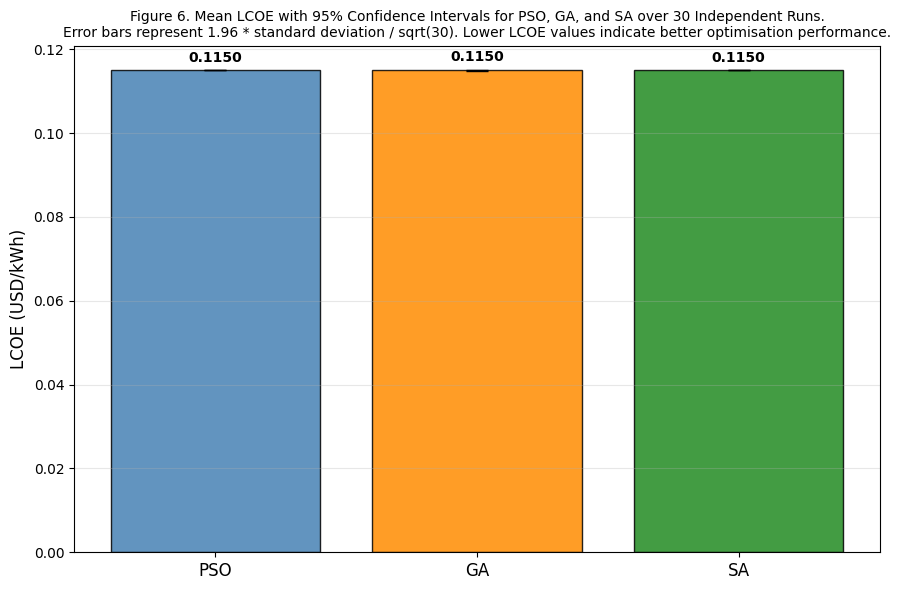

Figure 6 saved


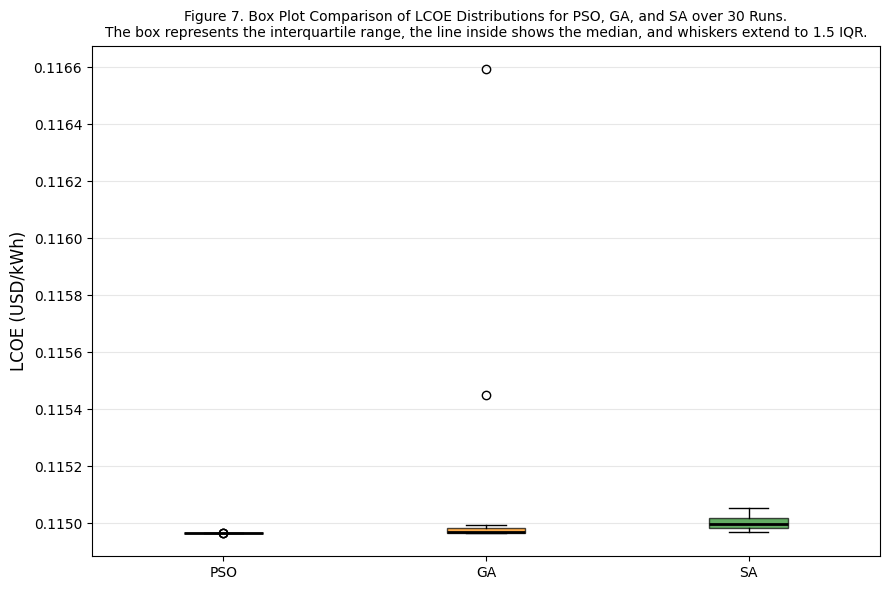

Figure 7 saved


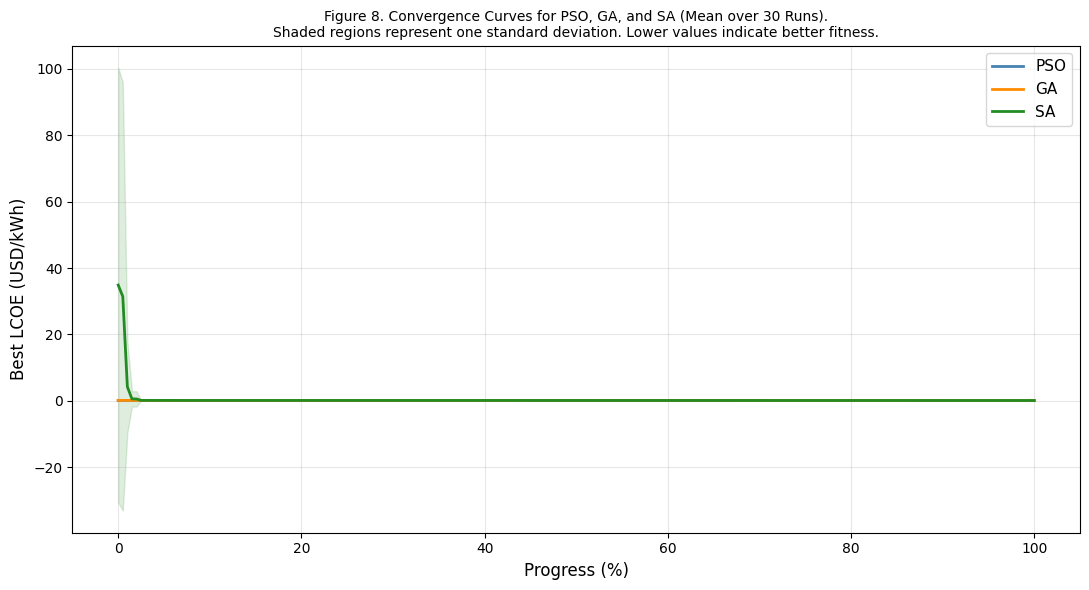

Figure 8 saved


In [ ]:
def plot_error_bars(pso_res, ga_res, sa_res):
    n = len(pso_res)
    algorithms = ['PSO', 'GA', 'SA']
    results_list = [pso_res, ga_res, sa_res]
    colors = ['steelblue', 'darkorange', 'forestgreen']

    means = [r.mean() for r in results_list]
    cis = [1.96 * r.std() / np.sqrt(n) for r in results_list]

    fig, ax = plt.subplots(figsize=(9, 6))
    x = np.arange(len(algorithms))
    bars = ax.bar(x, means, yerr=cis, capsize=8, color=colors,
                  edgecolor='black', alpha=0.85, error_kw={'linewidth': 2})

    for i, (mean, ci) in enumerate(zip(means, cis)):
        ax.text(i, mean + ci + 0.002, f'{mean:.4f}', ha='center', fontsize=10, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(algorithms, fontsize=12)
    ax.set_ylabel('LCOE (USD/kWh)', fontsize=12)
    ax.set_title('Figure 6. Mean LCOE with 95% Confidence Intervals for PSO, GA, and SA over 30 Independent Runs.\nError bars represent 1.96 * standard deviation / sqrt(30). Lower LCOE values indicate better optimisation performance.', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_FOLDER}/Figure_6_error_bars.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Figure 6 saved')

def plot_box_plots(pso_res, ga_res, sa_res):
    fig, ax = plt.subplots(figsize=(9, 6))
    data = [pso_res, ga_res, sa_res]
    bp = ax.boxplot(data, labels=['PSO', 'GA', 'SA'], patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2})
    colors = ['steelblue', 'darkorange', 'forestgreen']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_ylabel('LCOE (USD/kWh)', fontsize=12)
    ax.set_title('Figure 7. Box Plot Comparison of LCOE Distributions for PSO, GA, and SA over 30 Runs.\nThe box represents the interquartile range, the line inside shows the median, and whiskers extend to 1.5 IQR.', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_FOLDER}/Figure_7_box_plots.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Figure 7 saved')

def plot_convergence_curves(pso_curves, ga_curves, sa_curves):
    fig, ax = plt.subplots(figsize=(11, 6))

    pso_array = np.array([c for c in pso_curves if len(c) == len(pso_curves[0])])
    ga_array = np.array([c for c in ga_curves if len(c) == len(ga_curves[0])])
    sa_array = np.array([c for c in sa_curves if len(c) == len(sa_curves[0])])

    for arr, color, label in [(pso_array, 'steelblue', 'PSO'),
                               (ga_array, 'darkorange', 'GA'),
                               (sa_array, 'forestgreen', 'SA')]:
        mean_conv = arr.mean(axis=0)
        std_conv = arr.std(axis=0)
        x = np.linspace(0, 100, len(mean_conv))
        ax.plot(x, mean_conv, color=color, linewidth=2, label=label)
        ax.fill_between(x, mean_conv - std_conv, mean_conv + std_conv, alpha=0.15, color=color)

    ax.set_xlabel('Progress (%)', fontsize=12)
    ax.set_ylabel('Best LCOE (USD/kWh)', fontsize=12)
    ax.set_title('Figure 8. Convergence Curves for PSO, GA, and SA (Mean over 30 Runs).\nShaded regions represent one standard deviation. Lower values indicate better fitness.', fontsize=10)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_FOLDER}/Figure_8_convergence_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Figure 8 saved')

plot_error_bars(pso_results, ga_results, sa_results)
plot_box_plots(pso_results, ga_results, sa_results)
plot_convergence_curves(pso_convergence_curves, ga_convergence_curves, sa_convergence_curves)

## Cell 15: Final Results Summary Table
I am generating a complete summary of the best solution found by each algorithm, including the optimal component sizes, LCOE, and LPSP. This table will be the main results table in Section 6 of my report.

In [ ]:
def generate_final_summary(pso_res, ga_res, sa_res,
                            pso_sol, ga_sol, sa_sol):
    print('=' * 70)
    print('FINAL RESULTS SUMMARY')
    print('=' * 70)

    algorithms = {'PSO': (pso_res, pso_sol), 'GA': (ga_res, ga_sol), 'SA': (sa_res, sa_sol)}

    summary_rows = []
    for name, (res, sol) in algorithms.items():
        lcoe, lpsp, diesel_e = simulate_hres(
            sol,
            df_climate['solar_irradiance'].values,
            df_climate['wind_speed'].values,
            load_profile
        )
        renewable_fraction = 1 - (diesel_e / load_profile.sum())
        row = {
            'Algorithm': name,
            'PV (kW)': round(sol[0], 2),
            'Wind (kW)': round(sol[1], 2),
            'Battery (kWh)': round(sol[2], 2),
            'Diesel (kW)': round(sol[3], 2),
            'Best LCOE': round(res.min(), 4),
            'Mean LCOE': round(res.mean(), 4),
            'Std LCOE': round(res.std(), 4),
            'LPSP (%)': round(lpsp * 100, 2),
            'RE Fraction (%)': round(renewable_fraction * 100, 2)
        }
        summary_rows.append(row)
        print(f'\n{name} Best Solution:')
        print(f'  PV: {sol[0]:.2f} kW   Wind: {sol[1]:.2f} kW   Battery: {sol[2]:.2f} kWh   Diesel: {sol[3]:.2f} kW')
        print(f'  LCOE: {lcoe:.4f} USD/kWh   LPSP: {lpsp*100:.2f}%   Renewable Fraction: {renewable_fraction*100:.2f}%')

    summary_df = pd.DataFrame(summary_rows)
    print('\nTable 1. Summary of Best Solutions Found by Each Algorithm')
    print(summary_df.to_string(index=False))

    summary_df.to_csv(f'{OUTPUT_FOLDER}/Table_1_final_results_summary.csv', index=False)
    print('\nResults table saved to Google Drive')
    return summary_df

summary_df = generate_final_summary(
    pso_results, ga_results, sa_results,
    best_pso_solution, best_ga_solution, best_sa_solution
)

FINAL RESULTS SUMMARY

PSO Best Solution:
  PV: 87.55 kW   Wind: 0.00 kW   Battery: 177.64 kWh   Diesel: 5.00 kW
  LCOE: 0.1150 USD/kWh   LPSP: 5.00%   Renewable Fraction: 90.05%

GA Best Solution:
  PV: 87.55 kW   Wind: 0.00 kW   Battery: 177.66 kWh   Diesel: 5.00 kW
  LCOE: 0.1150 USD/kWh   LPSP: 5.00%   Renewable Fraction: 90.05%

SA Best Solution:
  PV: 87.48 kW   Wind: 0.00 kW   Battery: 177.92 kWh   Diesel: 5.00 kW
  LCOE: 0.1150 USD/kWh   LPSP: 5.00%   Renewable Fraction: 90.08%

Table 1. Summary of Best Solutions Found by Each Algorithm
Algorithm  PV (kW)  Wind (kW)  Battery (kWh)  Diesel (kW)  Best LCOE  Mean LCOE  Std LCOE  LPSP (%)  RE Fraction (%)
      PSO    87.55        0.0         177.64          5.0      0.115      0.115    0.0000       5.0            90.05
       GA    87.55        0.0         177.66          5.0      0.115      0.115    0.0003       5.0            90.05
       SA    87.48        0.0         177.92          5.0      0.115      0.115    0.0000       5.

## Cell 16: List All Saved Output Files
Finally I am listing all the files that have been saved to my Google Drive folder so I can confirm everything is there before I start writing my report.

In [ ]:
print('Files saved in Husamuddin outputs folder:')
print('=' * 50)
for filename in sorted(os.listdir(OUTPUT_FOLDER)):
    filepath = os.path.join(OUTPUT_FOLDER, filename)
    size_kb = os.path.getsize(filepath) / 1024
    print(f'  {filename:<45} {size_kb:.1f} KB')
print('\nAll outputs saved successfully. Ready to write the report.')

Files saved in Husamuddin outputs folder:
  Figure_1_2_3_climate_resources.png            411.5 KB
  Figure_4_5_load_profile.png                   231.4 KB
  Figure_6_error_bars.png                       137.4 KB
  Figure_7_box_plots.png                        134.0 KB
  Figure_8_convergence_curves.png               153.8 KB
  Table_1_final_results_summary.csv             0.3 KB
  ga_best_solution.npy                          0.2 KB
  ga_results.npy                                0.4 KB
  load_profile.npy                              68.6 KB
  nasa_power_ladakh_2022.csv                    297.2 KB
  pso_best_solution.npy                         0.2 KB
  pso_results.npy                               0.4 KB
  sa_best_solution.npy                          0.2 KB
  sa_results.npy                                0.4 KB
  statistical_results.json                      0.4 KB

All outputs saved successfully. Ready to write the report.
